In [1]:
from fastai.vision.all import *


/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [2]:
labels = pd.read_csv("../input/dog-breed-identification/labels.csv")
labels


,id,breed
0,8406d837b2d7fac1c3cd621abb4c4f9e,west_highland_white_terrier
1,e270622b5ffec8294d7e7628c4ff6c1e,brittany_spaniel
2,41295c36303043fc587e791b14ef2272,basset
3,b63b0200ddbb97df81972b26574959ab,boxer
4,2c64e362c9aa29450082291264dcba29,flat-coated_retriever
...,...,...
9194,e7af8f590b4fbdca0779f5e606ef91a1,german_shepherd
9195,79deb223049ef9f441f3fcf989897d29,great_pyrenees
9196,511bfe35ff282294f6129c55bd6c33f6,malinois
9197,f7a8a885e2b28630634c3fb513277f27,lhasa


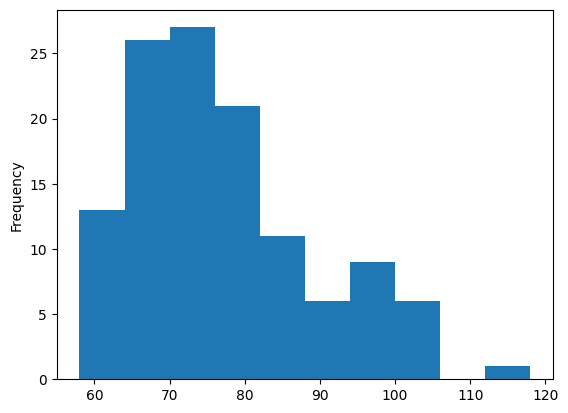

In [3]:
labels["breed"].value_counts().plot(kind="hist");


In [4]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_ids, valid_ids = next(split.split(labels, labels["breed"]))
labels["is_valid"] = [i in valid_ids for i in range(len(labels))]

labels["id"] = labels["id"].apply(lambda x: x + ".jpg")


In [5]:
path = "../input/dog-breed-identification/train"

def get_dls(size, bs):
    return ImageDataLoaders.from_df(labels, path,
                               item_tfms=Resize(460),
                               batch_tfms=[*aug_transforms(size=size),
                                           Normalize.from_stats(*imagenet_stats)],
                               bs=bs, val_bs=bs, valid_col="is_valid")

dls = get_dls(224, 64)


/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)
/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)
/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels 

/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)


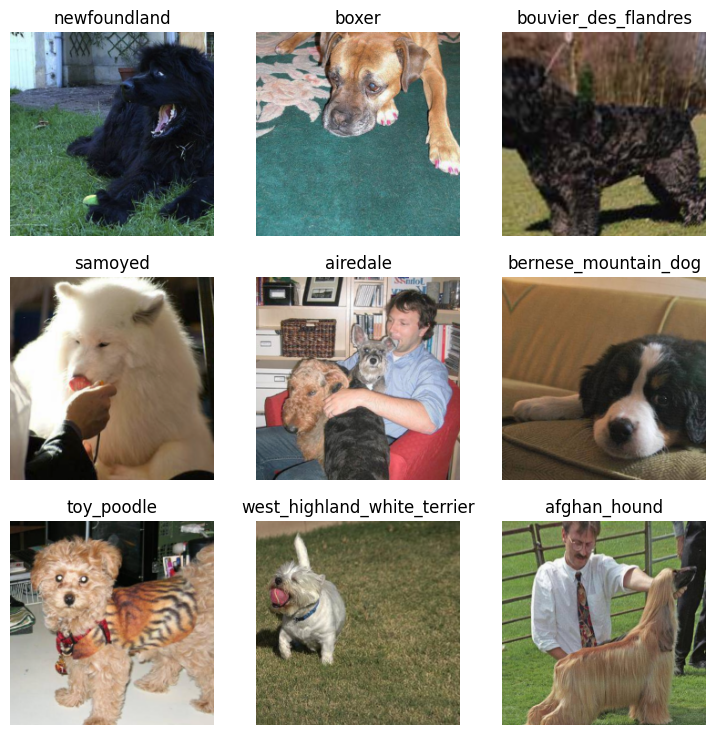

In [6]:
dls.show_batch()


In [7]:
def log_loss(inputs, targ, weights=None):
    preds = torch.softmax(inputs, dim=1)
    
    if weights is not None:
        weights = weights[targ].view(-1, 1)
        preds = preds * weights
        
    return -1.0 * preds.gather(1, targ.view(-1, 1)).log().mean()


In [8]:
class Log_loss(Module):
    def __init__(self, weights):
        self.weights = weights
    
    def forward(self, inputs, targs):
        return self.log_loss(inputs, targs, self.weights)
    
    def log_loss(self, inputs, targ, weights):
        preds = torch.softmax(inputs, dim=1)
        weights = weights[targ].view(-1, 1)
        preds = preds * weights
        return -1.0 * preds.gather(1, targ.view(-1, 1)).log().mean()


In [9]:
label_count = labels["breed"].value_counts()
n_samples = labels.shape[0]
n_classes = len(dls.vocab)
weights = [n_samples / (n_classes * label_count[breed]) for breed in dls.vocab]
weights = tensor(weights, device="cuda")

loss_func = Log_loss(weights)


In [10]:
learn = cnn_learner(dls, resnet50, loss_func=loss_func, 
                    metrics=log_loss, path=".").to_fp16()


/usr/local/lib/python3.11/dist-packages/fastai/vision/learner.py:303: UserWarning: `cnn_learner` has been renamed to `vision_learner` -- please update your code
  warn("`cnn_learner` has been renamed to `vision_learner` -- please update your code")
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 115MB/s]


/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)
/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)
/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels 

SuggestedLRs(valley=0.0012022644514217973)

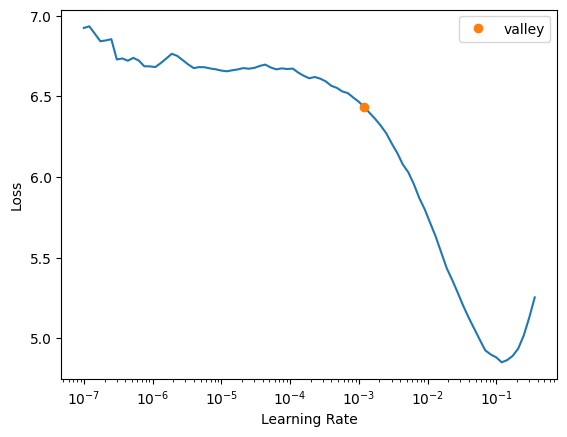

In [11]:
learn.lr_find()


In [12]:
learn.fit_one_cycle(1, 5e-3)


epoch,train_loss,valid_loss,log_loss,time
0,1.626506,0.599309,0.587069,00:14


/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)
/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)
/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels 

/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)
/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)
/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels 

SuggestedLRs(valley=0.0002754228771664202)

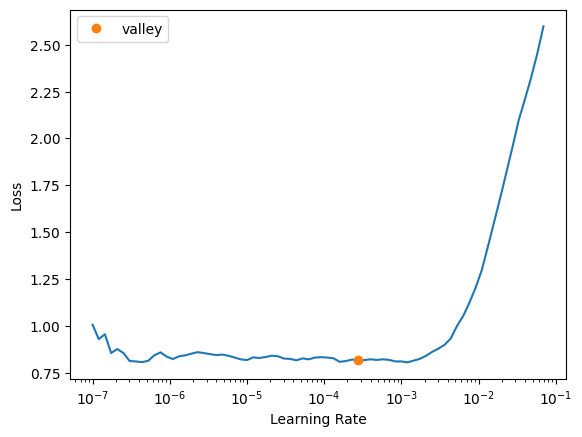

In [13]:
learn.unfreeze()
learn.lr_find()


In [14]:
learn.fit_one_cycle(5, 1e-4)


epoch,train_loss,valid_loss,log_loss,time
0,0.726651,0.516554,0.504314,00:15
1,0.615834,0.498205,0.485965,00:15
2,0.476525,0.492908,0.480668,00:15
3,0.357431,0.471346,0.459105,00:16
4,0.307296,0.471774,0.459533,00:16


/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)
/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o = r[c] if isinstance(c, int) or not c in getattr(r, '_fields', []) else getattr(r, c)
/usr/local/lib/python3.11/dist-packages/fastai/data/transforms.py:214: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels 

In [15]:
test_files = get_image_files("../input/dog-breed-identification/test")
test_dl = dls.test_dl(test_files, bs=16)


In [16]:
preds, targs = learn.tta(dl=test_dl)


In [17]:
preds = torch.softmax(preds, dim=1)
sub = pd.DataFrame({"id":test_files.map(lambda x:x.stem)})
sub[list(dls.vocab)] = preds
sub.to_csv("submission.csv", index=False)


/tmp/ipykernel_11/4174377554.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sub[list(dls.vocab)] = preds
/tmp/ipykernel_11/4174377554.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sub[list(dls.vocab)] = preds
/tmp/ipykernel_11/4174377554.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  

In [18]:
sub


,id,affenpinscher,afghan_hound,african_hunting_dog,airedale,american_staffordshire_terrier,appenzeller,australian_terrier,basenji,basset,...,toy_poodle,toy_terrier,vizsla,walker_hound,weimaraner,welsh_springer_spaniel,west_highland_white_terrier,whippet,wire-haired_fox_terrier,yorkshire_terrier
0,bca88d42e4fc84b3169b13a615f5fdbf,1.093729e-08,2.935479e-09,1.654108e-09,3.174397e-09,2.264183e-05,5.893908e-08,1.161323e-08,7.280376e-05,8.163176e-08,...,7.213241e-09,9.026963e-07,2.517191e-06,1.337197e-06,1.739016e-07,2.324558e-08,7.136170e-09,1.340247e-03,2.230871e-08,1.212126e-08
1,53cb3ed2547cdaf15ec7983d8325f007,3.503647e-07,4.808289e-07,3.108003e-08,2.822452e-08,1.455132e-07,6.043238e-07,1.086701e-06,1.833121e-06,2.694582e-06,...,4.955961e-07,1.361890e-07,1.242541e-04,3.288790e-05,2.067837e-06,6.262224e-06,7.408536e-08,6.704302e-07,1.965158e-07,2.504279e-06
2,726ca22c7c9c7b1043c7563a5a494cf9,1.642161e-05,3.990156e-05,3.332649e-06,2.654684e-04,3.019473e-06,1.259972e-06,1.183322e-06,1.950127e-07,3.185720e-07,...,9.579485e-05,3.443533e-07,2.263016e-07,8.713764e-07,2.940200e-06,2.150178e-07,1.337047e-05,3.611493e-06,5.723159e-06,1.916368e-05
3,48dc00c33b5f03e83f391fa306cf6c9e,1.821629e-05,1.514758e-06,1.239752e-07,1.732345e-06,7.990683e-07,2.212391e-07,9.264971e-07,4.149340e-07,1.371292e-06,...,1.008704e-05,8.782575e-08,1.134363e-06,5.637482e-07,9.404628e-07,7.855369e-08,1.630693e-06,1.087486e-07,2.401511e-05,6.381187e-07
4,7cbde2616a11273a406b99a55d18745e,3.114092e-05,8.808689e-06,7.617678e-05,3.696323e-05,7.452830e-06,3.297063e-03,4.349240e-05,2.485802e-04,2.405134e-04,...,1.012857e-06,2.946742e-04,3.875785e-04,1.789352e-02,3.947165e-04,6.564066e-06,1.127030e-06,1.120883e-05,3.240327e-05,1.528044e-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1018,c05756fc992ab5863853dafe9cf50675,1.467886e-04,8.480811e-03,1.289995e-04,2.702041e-03,1.982547e-05,2.282187e-04,9.444617e-04,2.435600e-05,5.933759e-05,...,6.752052e-05,1.243679e-05,1.764223e-04,1.282836e-03,7.310518e-05,1.706561e-05,6.703415e-06,4.189886e-05,2.197548e-03,1.096605e-05
1019,a6d7c6cc8162c58d6f75d6f46cd6e0d4,1.585087e-05,2.477241e-06,2.417485e-05,4.247612e-05,4.429868e-02,1.441697e-05,4.960845e-07,2.235058e-05,2.279078e-06,...,1.462039e-06,1.355135e-05,5.878636e-06,3.502959e-05,2.531107e-05,1.456828e-06,9.413478e-06,1.113348e-05,3.222216e-06,1.116171e-06
1020,482e38ca587e19af6e2dfa5532da7347,5.891508e-07,5.412312e-08,4.658844e-06,9.997660e-07,2.407570e-08,2.029702e-04,2.071224e-07,3.692654e-06,1.780596e-07,...,1.353908e-08,1.535199e-06,1.692789e-06,1.085633e-06,2.605937e-07,1.132602e-07,6.858946e-08,1.669642e-07,1.139614e-07,3.883855e-08
1021,c43f8987dc2992971f4316cecc4cad73,4.683111e-06,8.084564e-06,1.047530e-05,1.684287e-05,2.245756e-06,7.215203e-07,5.550955e-03,1.032297e-05,9.183995e-07,...,1.410386e-05,7.302569e-06,4.017691e-06,6.817702e-08,4.642149e-06,7.016398e-06,1.199599e-03,4.202943e-07,1.818885e-05,2.200021e-04
